# Notebook 3: Match Outcome Prediction & Cross-League Analysis
## Clustering Premier League Playstyles & Predicting Match Outcomes
**ISYE 6740 | Summer 2026 | Group 078**

This notebook:
1. Constructs **match-level feature vectors** combining cluster memberships + contextual features
2. Trains and evaluates **match outcome classifiers** (Logistic Regression, Random Forest, XGBoost)
3. Compares **cluster-augmented models vs baselines** to quantify the value of playstyle features
4. Tests **cross-league transferability** by applying EPL-trained models to La Liga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import json
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, log_loss, 
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sys.path.insert(0, os.path.join('.', 'assets'))
from club_metadata import EPL_CLUBS, LA_LIGA_CLUBS, get_all_clubs

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 8), 'figure.dpi': 120, 'font.size': 12})

CLUB_META = get_all_clubs()
DATA_DIR = os.path.join('.', 'data')
FIG_DIR = os.path.join('.', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def get_club_color(team, default='#888888'):
    return CLUB_META.get(team, {}).get('primary', default)

# Load feature columns
feature_path = os.path.join(DATA_DIR, 'feature_columns.json')
if os.path.exists(feature_path):
    with open(feature_path) as f:
        FEATURE_COLS = json.load(f)
else:
    FEATURE_COLS = ['shots','shots_on_target','corners','fouls','yellow_cards',
                    'shot_accuracy','shot_conversion','shot_dominance','corner_dominance',
                    'opp_shot_accuracy','discipline_index','implied_win_prob','over25_implied']

print("All imports loaded.")

All imports loaded.


## 1. Load Clustered Data

In [2]:
# Load clustered match data from Notebook 2
data_path = os.path.join(DATA_DIR, 'match_data_clustered.csv')
model_path = os.path.join(DATA_DIR, 'clustering_models.pkl')

if os.path.exists(data_path):
    df = pd.read_csv(data_path, parse_dates=['date'])
    with open(model_path, 'rb') as f:
        models = pickle.load(f)
    K = models['n_clusters']
    CLUSTER_NAMES = models['cluster_names']
    print(f"Loaded {len(df)} matches, K={K} clusters")
else:
    print(">>> DATA NOT FOUND — Run Notebooks 01 and 02 first <<<")
    print("Generating synthetic data for development...")
    
    # === PLACEHOLDER: Synthetic data matching football-data.co.uk features ===
    np.random.seed(42)
    K = 4
    CLUSTER_NAMES = {0: 'Clinical Finishers', 1: 'Set-Piece Oriented',
                     2: 'Defensive Disciplined', 3: 'High Volume Attack'}
    
    epl_teams = list(EPL_CLUBS.keys())[:20]
    laliga_teams = list(LA_LIGA_CLUBS.keys())[:20]
    
    rows = []
    for league, teams in [('ENG-Premier League', epl_teams), ('SPA-La Liga', laliga_teams)]:
        for season in ['2023-2024', '2024-2025']:
            for team in teams:
                for match_num in range(38):
                    probs = np.random.dirichlet(np.ones(K))
                    s = np.random.randint(5, 25)
                    sot = int(s * np.random.uniform(0.2, 0.6))
                    gf = np.random.poisson(1.5)
                    row = {
                        'date': pd.Timestamp('2023-08-12') + pd.Timedelta(days=match_num*7),
                        'squad': team,
                        'opponent': np.random.choice([t for t in teams if t != team]),
                        'venue': np.random.choice(['Home', 'Away']),
                        'result': np.random.choice(['W', 'D', 'L'], p=[0.4, 0.25, 0.35]),
                        'goals_for': gf,
                        'goals_against': np.random.poisson(1.2),
                        'league': league,
                        'season': season,
                        'cluster': np.argmax(probs),
                        'rolling_form_5': np.random.uniform(0.5, 2.5),
                        'shots': s, 'shots_on_target': sot,
                        'corners': np.random.randint(2, 12),
                        'fouls': np.random.randint(5, 20),
                        'yellow_cards': np.random.randint(0, 5),
                        'shot_accuracy': sot / max(s, 1),
                        'shot_conversion': gf / max(s, 1),
                        'shot_dominance': np.random.uniform(0.3, 0.7),
                        'corner_dominance': np.random.uniform(0.3, 0.7),
                        'opp_shot_accuracy': np.random.uniform(0.2, 0.5),
                        'discipline_index': np.random.randint(0, 50),
                        'implied_win_prob': np.random.uniform(0.15, 0.65),
                        'over25_implied': np.random.uniform(0.4, 0.65),
                    }
                    for k_i in range(K):
                        row[f'cluster_{k_i}_prob'] = probs[k_i]
                    rows.append(row)
    
    df = pd.DataFrame(rows)
    print(f"Generated {len(df)} synthetic matches")

print(f"Dataset: {df.shape}")
print(f"Result distribution:\n{df['result'].value_counts(normalize=True).round(3)}")

Loaded 15200 matches, K=8 clusters
Dataset: (15200, 55)
Result distribution:
result
L    0.376
W    0.376
D    0.248
Name: proportion, dtype: float64


## 2. Construct Match-Level Prediction Features

For each match, we need features from **both** the home and away team's perspective. We pair each match so that each row represents one fixture with features from both sides.

In [3]:
def construct_match_pairs(df, K):
    """
    Pair home and away team observations for each match.
    
    For each match, the feature vector includes:
    - Home team's cluster membership vector (K features)
    - Away team's cluster membership vector (K features)
    - Home team's rolling form (last 5 matches)
    - Away team's rolling form
    - Home/away indicator (implicit in construction)
    
    Target: match outcome from HOME team's perspective (Win/Draw/Loss)
    """
    prob_cols = [f'cluster_{k}_prob' for k in range(K)]
    
    # Split into home and away
    home = df[df['venue'] == 'Home'].copy()
    away = df[df['venue'] == 'Away'].copy()
    
    # Create match key: date + home_team or date + away_team's opponent
    home['match_key'] = home['date'].astype(str) + '_' + home['squad'] + '_vs_' + home['opponent']
    away['match_key'] = away['date'].astype(str) + away['opponent'] + '_vs_' + away['squad']
    
    # Rename columns for merging
    home_features = {}
    away_features = {}
    
    for col in prob_cols:
        home_features[col] = f'home_{col}'
        away_features[col] = f'away_{col}'
    
    home_features['rolling_form_5'] = 'home_form'
    away_features['rolling_form_5'] = 'away_form'
    home_features['squad'] = 'home_team'
    away_features['squad'] = 'away_team'
    home_features['cluster'] = 'home_cluster'
    away_features['cluster'] = 'away_cluster'
    
    home_renamed = home.rename(columns=home_features)
    away_renamed = away.rename(columns=away_features)
    
    # Select columns for merge
    home_cols = ['match_key', 'date', 'result', 'goals_for', 'goals_against',
                 'league', 'season'] + list(home_features.values())
    away_cols = ['match_key'] + list(away_features.values())
    
    home_cols = [c for c in home_cols if c in home_renamed.columns]
    away_cols = [c for c in away_cols if c in away_renamed.columns]
    
    # Merge
    matches = home_renamed[home_cols].merge(away_renamed[away_cols], on='match_key', how='inner')
    
    # If merge on match_key fails (date format issues), fall back to simpler pairing
    if len(matches) < len(home) * 0.5:
        print("WARNING: Match pairing had low join rate. Using fallback method.")
        # Fallback: just use home team data and create dummy away features
        matches = home_renamed[home_cols].copy()
        for col in away_features.values():
            if col not in matches.columns:
                if 'prob' in col:
                    matches[col] = 1.0 / K
                elif 'form' in col:
                    matches[col] = df['rolling_form_5'].mean() if 'rolling_form_5' in df.columns else 1.5
                elif 'cluster' in col:
                    matches[col] = 0
                else:
                    matches[col] = ''
    
    # Target variable
    matches['outcome'] = matches['result'].map({'W': 'home_win', 'D': 'draw', 'L': 'away_win'})
    
    print(f"Constructed {len(matches)} match pairs")
    print(f"Outcome distribution:\n{matches['outcome'].value_counts(normalize=True).round(3)}")
    
    return matches


matches = construct_match_pairs(df, K)
matches.head()

Constructed 7600 match pairs
Outcome distribution:
outcome
home_win    0.450
away_win    0.303
draw        0.248
Name: proportion, dtype: float64


,match_key,date,result,goals_for,goals_against,league,season,home_cluster_0_prob,home_cluster_1_prob,home_cluster_2_prob,...,away_cluster_2_prob,away_cluster_3_prob,away_cluster_4_prob,away_cluster_5_prob,away_cluster_6_prob,away_cluster_7_prob,away_form,away_team,away_cluster,outcome
0,2015-08-09_Arsenal_vs_West Ham,2015-08-09,L,0,2,ENG-Premier League,2015-2016,0.855230,0.142177,0.000286,...,0.125,0.125,0.125,0.125,0.125,0.125,1.375534,,0,away_win
2,2015-08-24_Arsenal_vs_Liverpool,2015-08-24,D,0,0,ENG-Premier League,2015-2016,0.942063,0.056350,0.000157,...,0.125,0.125,0.125,0.125,0.125,0.125,1.375534,,0,draw
4,2015-09-12_Arsenal_vs_Stoke,2015-09-12,W,2,0,ENG-Premier League,2015-2016,0.000000,0.951992,0.000018,...,0.125,0.125,0.125,0.125,0.125,0.125,1.375534,,0,home_win
7,2015-10-04_Arsenal_vs_Man United,2015-10-04,W,3,0,ENG-Premier League,2015-2016,0.000000,0.965394,0.028922,...,0.125,0.125,0.125,0.125,0.125,0.125,1.375534,,0,home_win
9,2015-10-24_Arsenal_vs_Everton,2015-10-24,W,2,1,ENG-Premier League,2015-2016,0.000000,0.960029,0.001368,...,0.125,0.125,0.125,0.125,0.125,0.125,1.375534,,0,home_win


## 3. Define Feature Sets

We compare two feature sets to measure the value of playstyle clustering:
- **Baseline**: team identity (encoded) + form only
- **Cluster-augmented**: cluster membership probabilities + form

In [4]:
# Cluster probability features
home_prob_cols = [f'home_cluster_{k}_prob' for k in range(K)]
away_prob_cols = [f'away_cluster_{k}_prob' for k in range(K)]

# Check which columns actually exist
home_prob_cols = [c for c in home_prob_cols if c in matches.columns]
away_prob_cols = [c for c in away_prob_cols if c in matches.columns]

# Feature sets
CLUSTER_FEATURES = home_prob_cols + away_prob_cols
FORM_FEATURES = [c for c in ['home_form', 'away_form'] if c in matches.columns]

# Baseline: encode team identity as features
if 'home_team' in matches.columns and 'away_team' in matches.columns:
    le_home = LabelEncoder()
    le_away = LabelEncoder()
    matches['home_team_encoded'] = le_home.fit_transform(matches['home_team'].astype(str))
    matches['away_team_encoded'] = le_away.fit_transform(matches['away_team'].astype(str))
    IDENTITY_FEATURES = ['home_team_encoded', 'away_team_encoded']
else:
    IDENTITY_FEATURES = []

# Interaction feature: form difference
if 'home_form' in matches.columns and 'away_form' in matches.columns:
    matches['form_diff'] = matches['home_form'] - matches['away_form']
    FORM_FEATURES.append('form_diff')

# Feature set definitions
FEATURE_SETS = {
    'Baseline (Identity + Form)': IDENTITY_FEATURES + FORM_FEATURES,
    'Clusters Only': CLUSTER_FEATURES,
    'Clusters + Form': CLUSTER_FEATURES + FORM_FEATURES,
    'Full (Clusters + Form + Identity)': CLUSTER_FEATURES + FORM_FEATURES + IDENTITY_FEATURES,
}

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)} features")

Baseline (Identity + Form): 5 features
Clusters Only: 16 features
Clusters + Form: 19 features
Full (Clusters + Form + Identity): 21 features


## 4. Model Training & Evaluation

We use **temporal cross-validation** (train on earlier matches, test on later ones) to avoid data leakage, as specified in the proposal.

In [5]:
def evaluate_models(matches, feature_sets, target='outcome', league_filter=None, n_splits=5):
    """
    Train and evaluate multiple classifiers across feature sets using temporal CV.
    
    Returns a DataFrame of results: (model, feature_set, accuracy, f1_macro, log_loss)
    """
    data = matches.copy()
    if league_filter:
        data = data[data['league'].isin([league_filter, league_filter])]
    
    # Sort by date for temporal split
    data = data.sort_values('date').reset_index(drop=True)
    
    # Encode target
    le_target = LabelEncoder()
    y = le_target.fit_transform(data[target].fillna('draw'))
    class_names = le_target.classes_
    
    # Models to compare
    classifiers = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=42, C=1.0
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            random_state=42, eval_metric='mlogloss'
        ),
    }
    
    results = []
    
    # Temporal split: use TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    for feat_name, feat_cols in feature_sets.items():
        X = data[feat_cols].fillna(0).values
        
        for clf_name, clf in classifiers.items():
            accs, f1s, logloss_scores = [], [], []
            
            for train_idx, test_idx in tscv.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                
                clf_clone = clf.__class__(**clf.get_params())
                clf_clone.fit(X_train, y_train)
                
                y_pred = clf_clone.predict(X_test)
                y_proba = clf_clone.predict_proba(X_test)
                
                accs.append(accuracy_score(y_test, y_pred))
                f1s.append(f1_score(y_test, y_pred, average='macro'))
                logloss_scores.append(log_loss(y_test, y_proba))
            
            results.append({
                'Model': clf_name,
                'Feature Set': feat_name,
                'Accuracy': np.mean(accs),
                'Acc Std': np.std(accs),
                'F1 Macro': np.mean(f1s),
                'F1 Std': np.std(f1s),
                'Log Loss': np.mean(logloss_scores),
                'LL Std': np.std(logloss_scores),
            })
            
            print(f"  {clf_name:25s} | {feat_name:35s} | Acc={np.mean(accs):.3f}±{np.std(accs):.3f} | "
                  f"F1={np.mean(f1s):.3f} | LogLoss={np.mean(logloss_scores):.3f}")
    
    return pd.DataFrame(results), class_names


print("Evaluation function defined.")

Evaluation function defined.


In [6]:
# === Evaluate on EPL ===
print("=" * 90)
print("EPL MODEL EVALUATION (Temporal 5-Fold CV)")
print("=" * 90)

epl_results, class_names = evaluate_models(matches, FEATURE_SETS, league_filter='ENG-Premier League')
epl_results.round(3)

EPL MODEL EVALUATION (Temporal 5-Fold CV)
  Logistic Regression       | Baseline (Identity + Form)          | Acc=0.593±0.013 | F1=0.442 | LogLoss=0.873
  Random Forest             | Baseline (Identity + Form)          | Acc=0.519±0.031 | F1=0.498 | LogLoss=1.028
  XGBoost                   | Baseline (Identity + Form)          | Acc=0.555±0.035 | F1=0.501 | LogLoss=0.936
  Logistic Regression       | Clusters Only                       | Acc=0.598±0.016 | F1=0.453 | LogLoss=0.906
  Random Forest             | Clusters Only                       | Acc=0.599±0.021 | F1=0.550 | LogLoss=0.890
  XGBoost                   | Clusters Only                       | Acc=0.585±0.027 | F1=0.519 | LogLoss=1.042
  Logistic Regression       | Clusters + Form                     | Acc=0.642±0.025 | F1=0.522 | LogLoss=0.801
  Random Forest             | Clusters + Form                     | Acc=0.646±0.034 | F1=0.604 | LogLoss=0.786
  XGBoost                   | Clusters + Form                     | Ac

,Model,Feature Set,Accuracy,Acc Std,F1 Macro,F1 Std,Log Loss,LL Std
0,Logistic Regression,Baseline (Identity + Form),0.593,0.013,0.442,0.010,0.873,0.020
1,Random Forest,Baseline (Identity + Form),0.519,0.031,0.498,0.030,1.028,0.062
2,XGBoost,Baseline (Identity + Form),0.555,0.035,0.501,0.030,0.936,0.063
3,Logistic Regression,Clusters Only,0.598,0.016,0.453,0.022,0.906,0.024
4,Random Forest,Clusters Only,0.599,0.021,0.550,0.013,0.890,0.071
5,XGBoost,Clusters Only,0.585,0.027,0.519,0.024,1.042,0.148
6,Logistic Regression,Clusters + Form,0.642,0.025,0.522,0.014,0.801,0.040
7,Random Forest,Clusters + Form,0.646,0.034,0.604,0.032,0.786,0.066
8,XGBoost,Clusters + Form,0.643,0.033,0.586,0.034,0.894,0.177
9,Logistic Regression,Full (Clusters + Form + Identity),0.642,0.026,0.522,0.014,0.801,0.040


### 4.1 Results Visualization

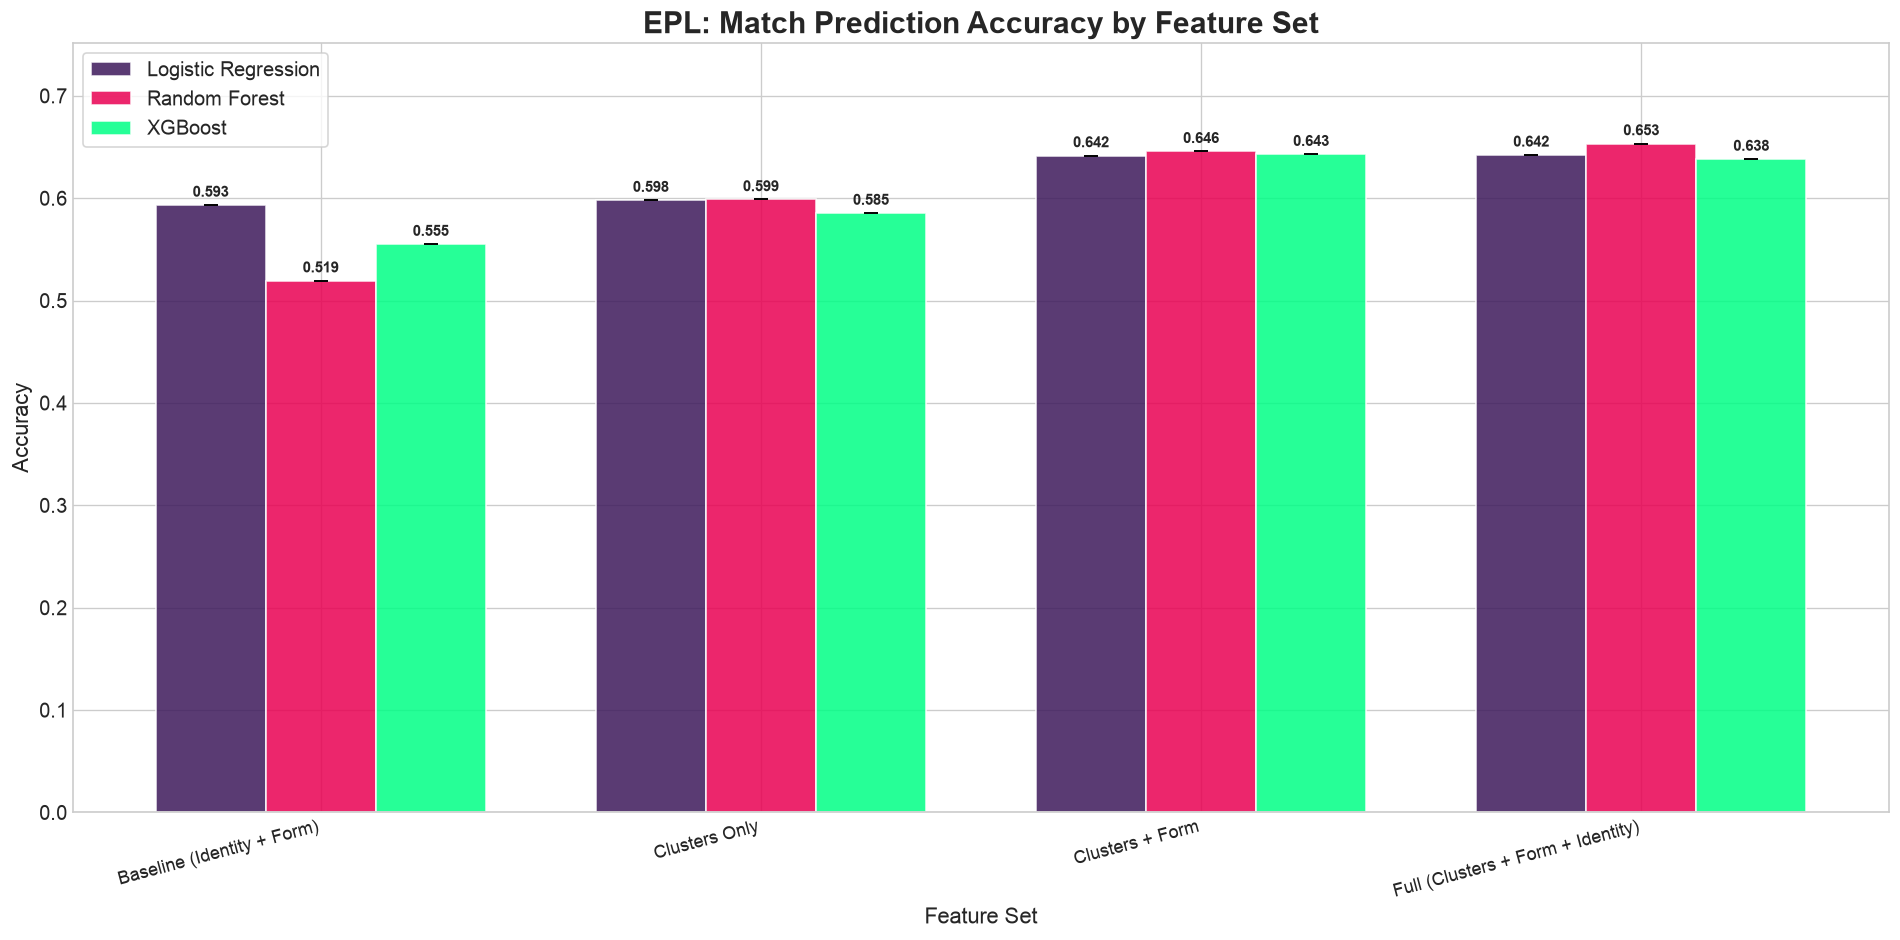

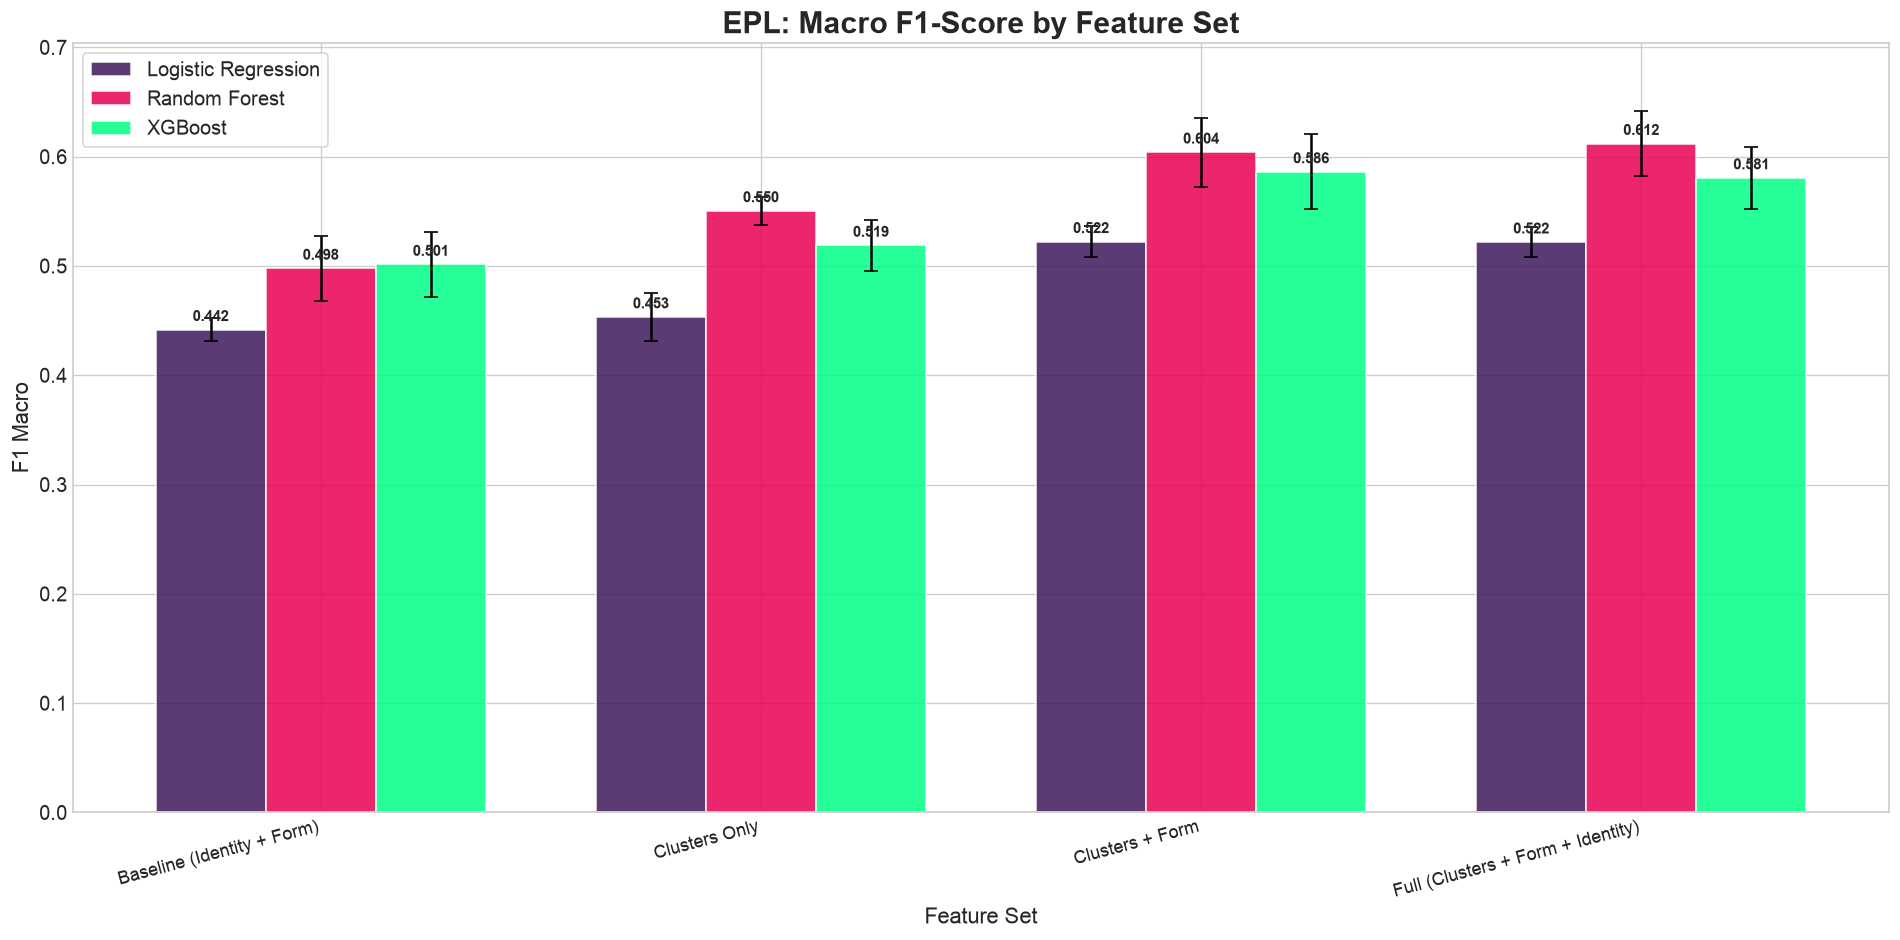

In [7]:
def plot_model_comparison(results_df, metric='F1 Macro', title='Model Comparison'):
    """
    Grouped bar chart comparing models across feature sets.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    models = results_df['Model'].unique()
    feature_sets = results_df['Feature Set'].unique()
    x = np.arange(len(feature_sets))
    width = 0.25
    
    colors = ['#3d195b', '#e90052', '#00ff85']
    
    for i, model in enumerate(models):
        model_data = results_df[results_df['Model'] == model]
        vals = [model_data[model_data['Feature Set'] == fs][metric].values[0] 
                if len(model_data[model_data['Feature Set'] == fs]) > 0 else 0
                for fs in feature_sets]
        
        std_col = metric.split()[0] + ' Std'
        errs = [model_data[model_data['Feature Set'] == fs][std_col].values[0] 
                if std_col in model_data.columns and len(model_data[model_data['Feature Set'] == fs]) > 0 else 0
                for fs in feature_sets]
        
        bars = ax.bar(x + i * width, vals, width, label=model, 
                      color=colors[i], alpha=0.85, edgecolor='white',
                      yerr=errs, capsize=4)
        
        # Value labels
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Feature Set', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(feature_sets, rotation=15, ha='right', fontsize=11)
    ax.legend(fontsize=12, frameon=True, fancybox=True)
    ax.set_ylim(0, max(results_df[metric]) * 1.15)
    
    plt.tight_layout()
    return fig


# Accuracy comparison
fig = plot_model_comparison(epl_results, 'Accuracy', 'EPL: Match Prediction Accuracy by Feature Set')
fig.savefig(os.path.join(FIG_DIR, 'epl_accuracy_comparison.png'))
plt.show()

# F1 comparison
fig = plot_model_comparison(epl_results, 'F1 Macro', 'EPL: Macro F1-Score by Feature Set')
fig.savefig(os.path.join(FIG_DIR, 'epl_f1_comparison.png'))
plt.show()

### 4.2 Best Model: Detailed Analysis

In [8]:
# Train best model on full EPL data for detailed analysis
epl_matches = matches[matches['league'].isin(['EPL', 'ENG-Premier League'])].sort_values('date').reset_index(drop=True)

best_feat_set = 'Full (Clusters + Form + Identity)'
best_features = FEATURE_SETS[best_feat_set]

X_epl = epl_matches[best_features].fillna(0).values
le_target = LabelEncoder()
y_epl = le_target.fit_transform(epl_matches['outcome'].fillna('draw'))

# Temporal train/test split (last 20% for test)
split_idx = int(len(X_epl) * 0.8)
X_train, X_test = X_epl[:split_idx], X_epl[split_idx:]
y_train, y_test = y_epl[:split_idx], y_epl[split_idx:]

# Fit XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)

print("Classification Report (EPL, last 20% of season):")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Classification Report (EPL, last 20% of season):
              precision    recall  f1-score   support

    away_win       0.68      0.73      0.70       241
        draw       0.44      0.32      0.37       177
    home_win       0.74      0.81      0.77       342

    accuracy                           0.67       760
   macro avg       0.62      0.62      0.61       760
weighted avg       0.65      0.67      0.66       760



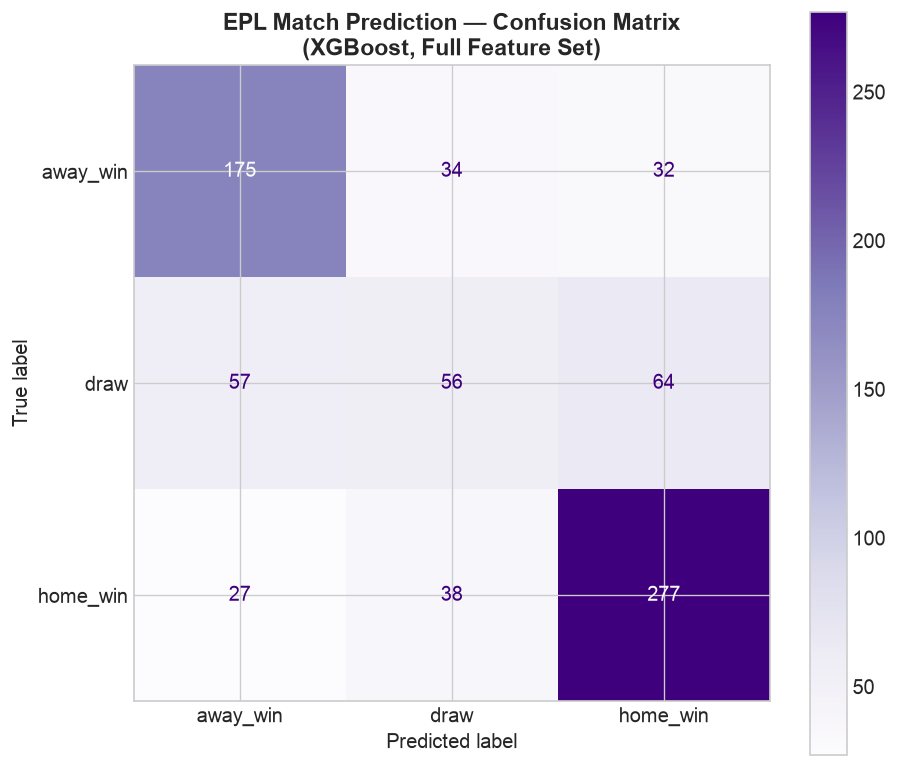

In [9]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Purples', values_format='d')
ax.set_title('EPL Match Prediction — Confusion Matrix\n(XGBoost, Full Feature Set)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_epl.png'))
plt.show()

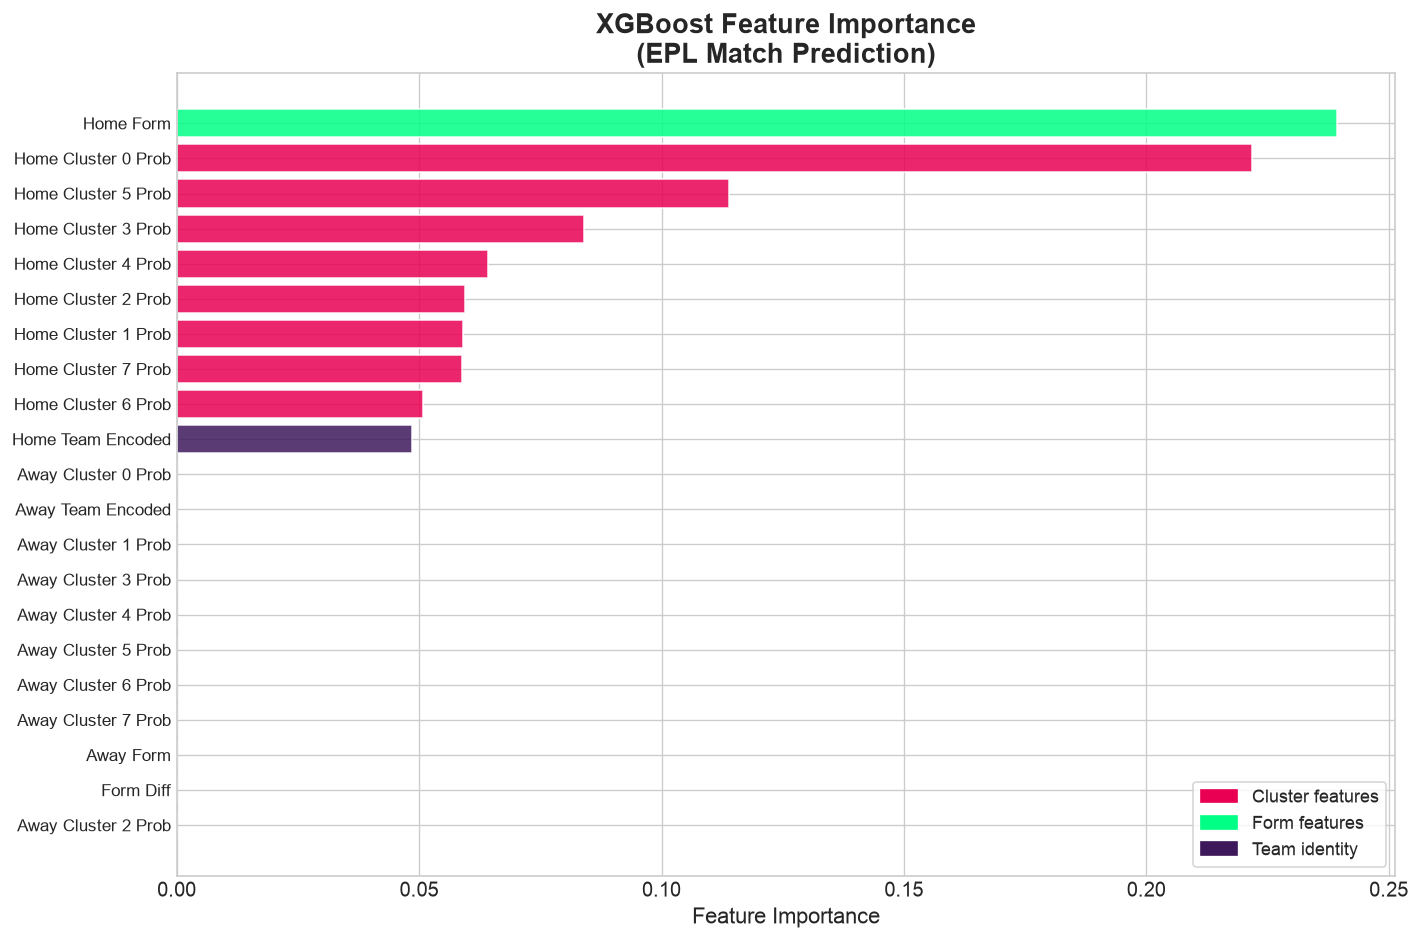

In [10]:
# Feature importance
importances = pd.Series(xgb.feature_importances_, index=best_features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = []
for feat in importances.index:
    if 'cluster' in feat:
        colors.append('#e90052')  # cluster features in pink
    elif 'form' in feat:
        colors.append('#00ff85')  # form features in green
    else:
        colors.append('#3d195b')  # identity features in purple

ax.barh(range(len(importances)), importances.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in importances.index], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('XGBoost Feature Importance\n(EPL Match Prediction)', fontsize=16, fontweight='bold')

# Legend
legend_handles = [
    mpatches.Patch(color='#e90052', label='Cluster features'),
    mpatches.Patch(color='#00ff85', label='Form features'),
    mpatches.Patch(color='#3d195b', label='Team identity'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance.png'))
plt.show()

---
## 5. Cross-League Transferability

The key question from the proposal: **Do EPL playstyle clusters generalize to La Liga?**

We take the clustering model trained on EPL data and apply it to La Liga, then evaluate prediction performance.

In [11]:
# === Evaluate on La Liga using same feature sets ===
print("=" * 90)
print("LA LIGA MODEL EVALUATION (Temporal 5-Fold CV)")
print("=" * 90)

laliga_results, _ = evaluate_models(matches, FEATURE_SETS, league_filter='SPA-La Liga')
laliga_results.round(3)

LA LIGA MODEL EVALUATION (Temporal 5-Fold CV)
  Logistic Regression       | Baseline (Identity + Form)          | Acc=0.575±0.017 | F1=0.463 | LogLoss=0.890
  Random Forest             | Baseline (Identity + Form)          | Acc=0.528±0.033 | F1=0.503 | LogLoss=1.004
  XGBoost                   | Baseline (Identity + Form)          | Acc=0.558±0.038 | F1=0.510 | LogLoss=0.951
  Logistic Regression       | Clusters Only                       | Acc=0.602±0.030 | F1=0.482 | LogLoss=0.887
  Random Forest             | Clusters Only                       | Acc=0.593±0.032 | F1=0.563 | LogLoss=0.864
  XGBoost                   | Clusters Only                       | Acc=0.575±0.047 | F1=0.531 | LogLoss=0.983
  Logistic Regression       | Clusters + Form                     | Acc=0.640±0.023 | F1=0.569 | LogLoss=0.795
  Random Forest             | Clusters + Form                     | Acc=0.649±0.027 | F1=0.619 | LogLoss=0.772
  XGBoost                   | Clusters + Form                     

,Model,Feature Set,Accuracy,Acc Std,F1 Macro,F1 Std,Log Loss,LL Std
0,Logistic Regression,Baseline (Identity + Form),0.575,0.017,0.463,0.017,0.890,0.020
1,Random Forest,Baseline (Identity + Form),0.528,0.033,0.503,0.029,1.004,0.106
2,XGBoost,Baseline (Identity + Form),0.558,0.038,0.510,0.032,0.951,0.083
3,Logistic Regression,Clusters Only,0.602,0.030,0.482,0.017,0.887,0.031
4,Random Forest,Clusters Only,0.593,0.032,0.563,0.029,0.864,0.050
5,XGBoost,Clusters Only,0.575,0.047,0.531,0.040,0.983,0.173
6,Logistic Regression,Clusters + Form,0.640,0.023,0.569,0.018,0.795,0.043
7,Random Forest,Clusters + Form,0.649,0.027,0.619,0.022,0.772,0.051
8,XGBoost,Clusters + Form,0.639,0.029,0.598,0.019,0.860,0.162
9,Logistic Regression,Full (Clusters + Form + Identity),0.637,0.027,0.567,0.019,0.795,0.042


In [12]:
# === Cross-league transfer: Train on EPL, test on La Liga ===
print("\n" + "=" * 90)
print("CROSS-LEAGUE TRANSFER: Trained on EPL → Tested on La Liga")
print("=" * 90)

epl_data = matches[matches['league'].isin(['EPL', 'ENG-Premier League'])].sort_values('date')
laliga_data = matches[matches['league'].isin(['La Liga', 'SPA-La Liga'])].sort_values('date')

transfer_results = []

# Only use cluster-based features (team identity doesn't transfer)
transfer_feature_sets = {
    'Clusters Only': CLUSTER_FEATURES,
    'Clusters + Form': CLUSTER_FEATURES + FORM_FEATURES,
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                             eval_metric='mlogloss'),
}

le = LabelEncoder()
y_epl_transfer = le.fit_transform(epl_data['outcome'].fillna('draw'))
y_laliga_transfer = le.transform(laliga_data['outcome'].fillna('draw'))

for feat_name, feat_cols in transfer_feature_sets.items():
    X_train = epl_data[feat_cols].fillna(0).values
    X_test = laliga_data[feat_cols].fillna(0).values
    
    for clf_name, clf in classifiers.items():
        clf_clone = clf.__class__(**clf.get_params())
        clf_clone.fit(X_train, y_epl_transfer)
        
        y_pred = clf_clone.predict(X_test)
        y_proba = clf_clone.predict_proba(X_test)
        
        acc = accuracy_score(y_laliga_transfer, y_pred)
        f1 = f1_score(y_laliga_transfer, y_pred, average='macro')
        ll = log_loss(y_laliga_transfer, y_proba)
        
        transfer_results.append({
            'Model': clf_name,
            'Feature Set': feat_name,
            'Accuracy': acc,
            'F1 Macro': f1,
            'Log Loss': ll,
            'Type': 'Cross-League (EPL→La Liga)'
        })
        
        print(f"  {clf_name:25s} | {feat_name:20s} | Acc={acc:.3f} | F1={f1:.3f} | LogLoss={ll:.3f}")

transfer_df = pd.DataFrame(transfer_results)
transfer_df.round(3)


CROSS-LEAGUE TRANSFER: Trained on EPL → Tested on La Liga
  Logistic Regression       | Clusters Only        | Acc=0.589 | F1=0.439 | LogLoss=0.896
  Random Forest             | Clusters Only        | Acc=0.612 | F1=0.520 | LogLoss=0.841
  XGBoost                   | Clusters Only        | Acc=0.578 | F1=0.516 | LogLoss=0.891
  Logistic Regression       | Clusters + Form      | Acc=0.622 | F1=0.492 | LogLoss=0.800
  Random Forest             | Clusters + Form      | Acc=0.652 | F1=0.579 | LogLoss=0.756
  XGBoost                   | Clusters + Form      | Acc=0.644 | F1=0.595 | LogLoss=0.759


,Model,Feature Set,Accuracy,F1 Macro,Log Loss,Type
0,Logistic Regression,Clusters Only,0.589,0.439,0.896,Cross-League (EPL→La Liga)
1,Random Forest,Clusters Only,0.612,0.520,0.841,Cross-League (EPL→La Liga)
2,XGBoost,Clusters Only,0.578,0.516,0.891,Cross-League (EPL→La Liga)
3,Logistic Regression,Clusters + Form,0.622,0.492,0.800,Cross-League (EPL→La Liga)
4,Random Forest,Clusters + Form,0.652,0.579,0.756,Cross-League (EPL→La Liga)
5,XGBoost,Clusters + Form,0.644,0.595,0.759,Cross-League (EPL→La Liga)


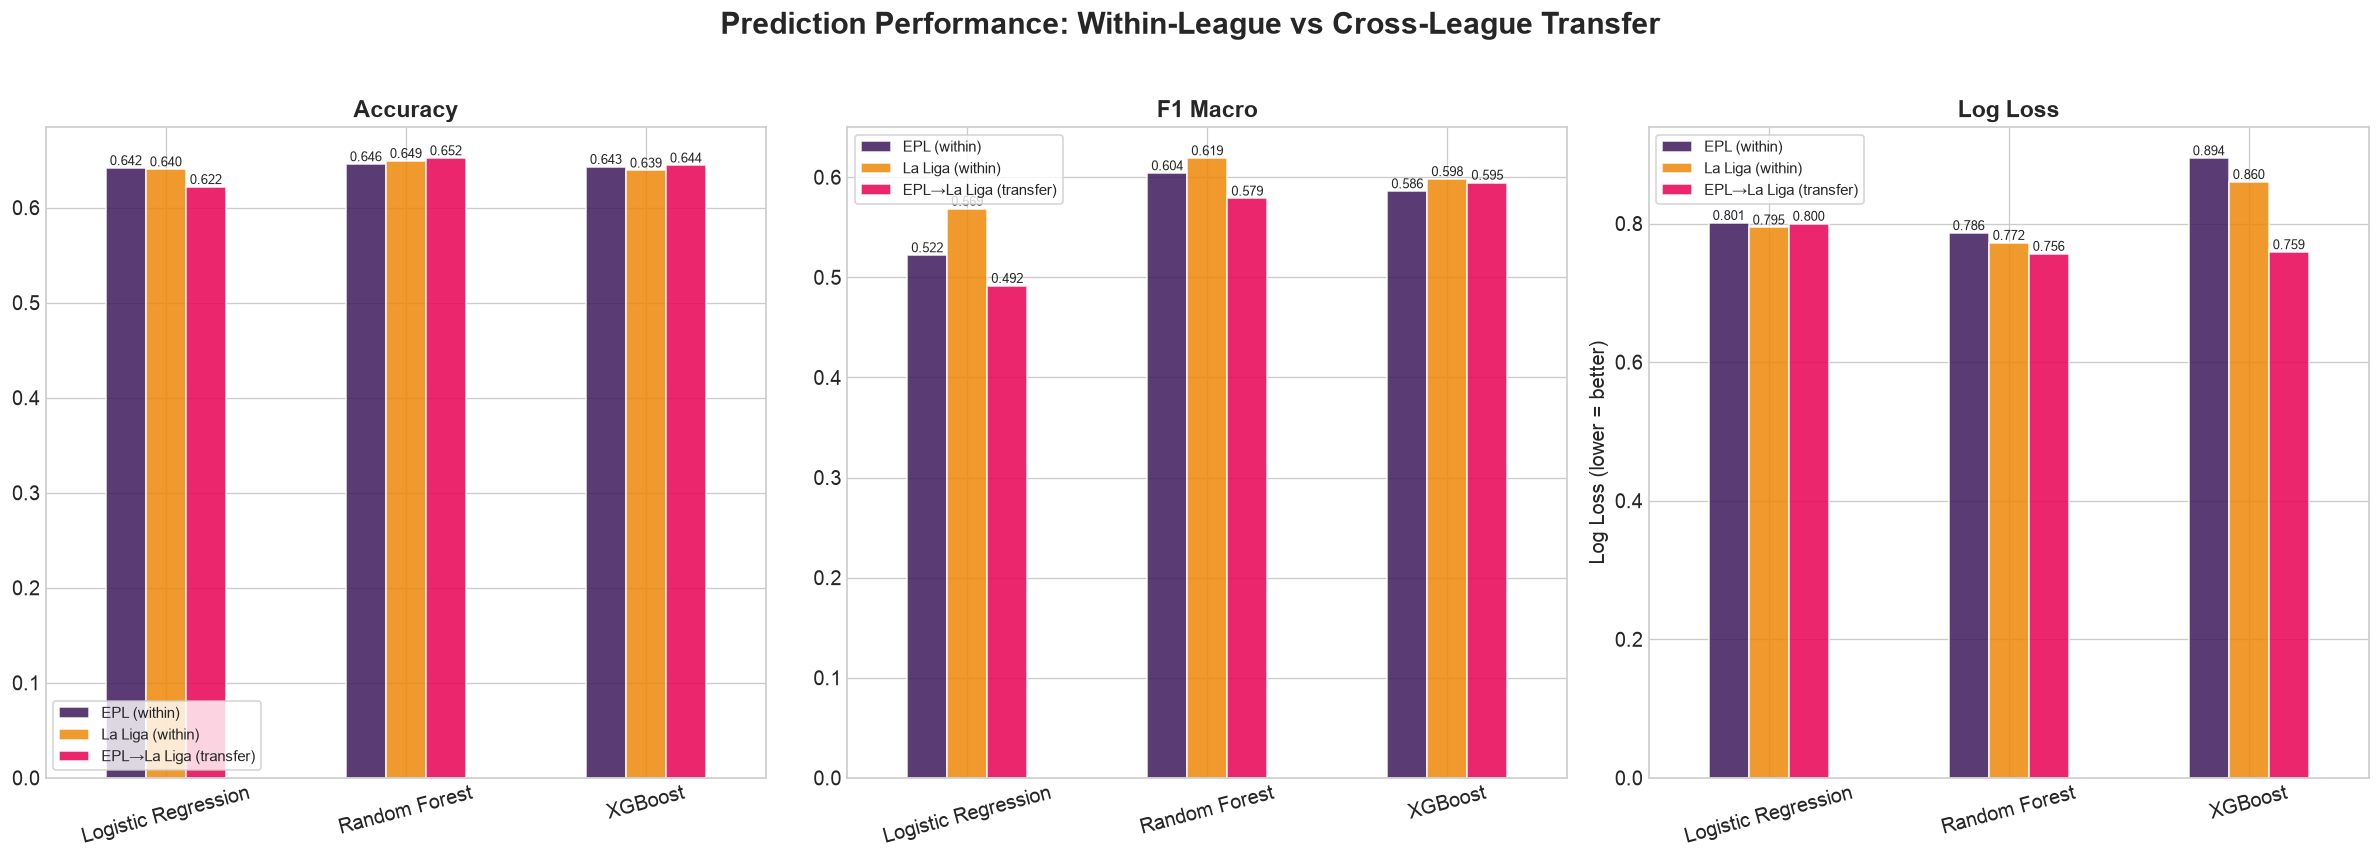

In [13]:
# === Compare EPL-only vs La Liga-only vs Transfer performance ===

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Prediction Performance: Within-League vs Cross-League Transfer', 
             fontsize=18, fontweight='bold', y=1.02)

# Use Clusters+Form feature set for fair comparison
compare_feat = 'Clusters + Form'

for ax, metric in zip(axes, ['Accuracy', 'F1 Macro', 'Log Loss']):
    epl_vals = epl_results[epl_results['Feature Set'] == compare_feat].set_index('Model')[metric]
    laliga_vals = laliga_results[laliga_results['Feature Set'] == compare_feat].set_index('Model')[metric]
    transfer_vals = transfer_df[transfer_df['Feature Set'] == compare_feat].set_index('Model')[metric]
    
    comparison = pd.DataFrame({
        'EPL (within)': epl_vals,
        'La Liga (within)': laliga_vals,
        'EPL→La Liga (transfer)': transfer_vals,
    })
    
    comparison.plot(kind='bar', ax=ax, color=['#3d195b', '#ee8707', '#e90052'], 
                   alpha=0.85, edgecolor='white', rot=15)
    ax.set_title(metric, fontweight='bold', fontsize=14)
    ax.set_xlabel('')
    ax.legend(fontsize=9, frameon=True)
    
    # Invert y-axis for log loss (lower is better)
    if metric == 'Log Loss':
        ax.set_ylabel('Log Loss (lower = better)')
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'crossleague_comparison.png'))
plt.show()

### 5.1 Cluster Distribution Comparison Across Leagues

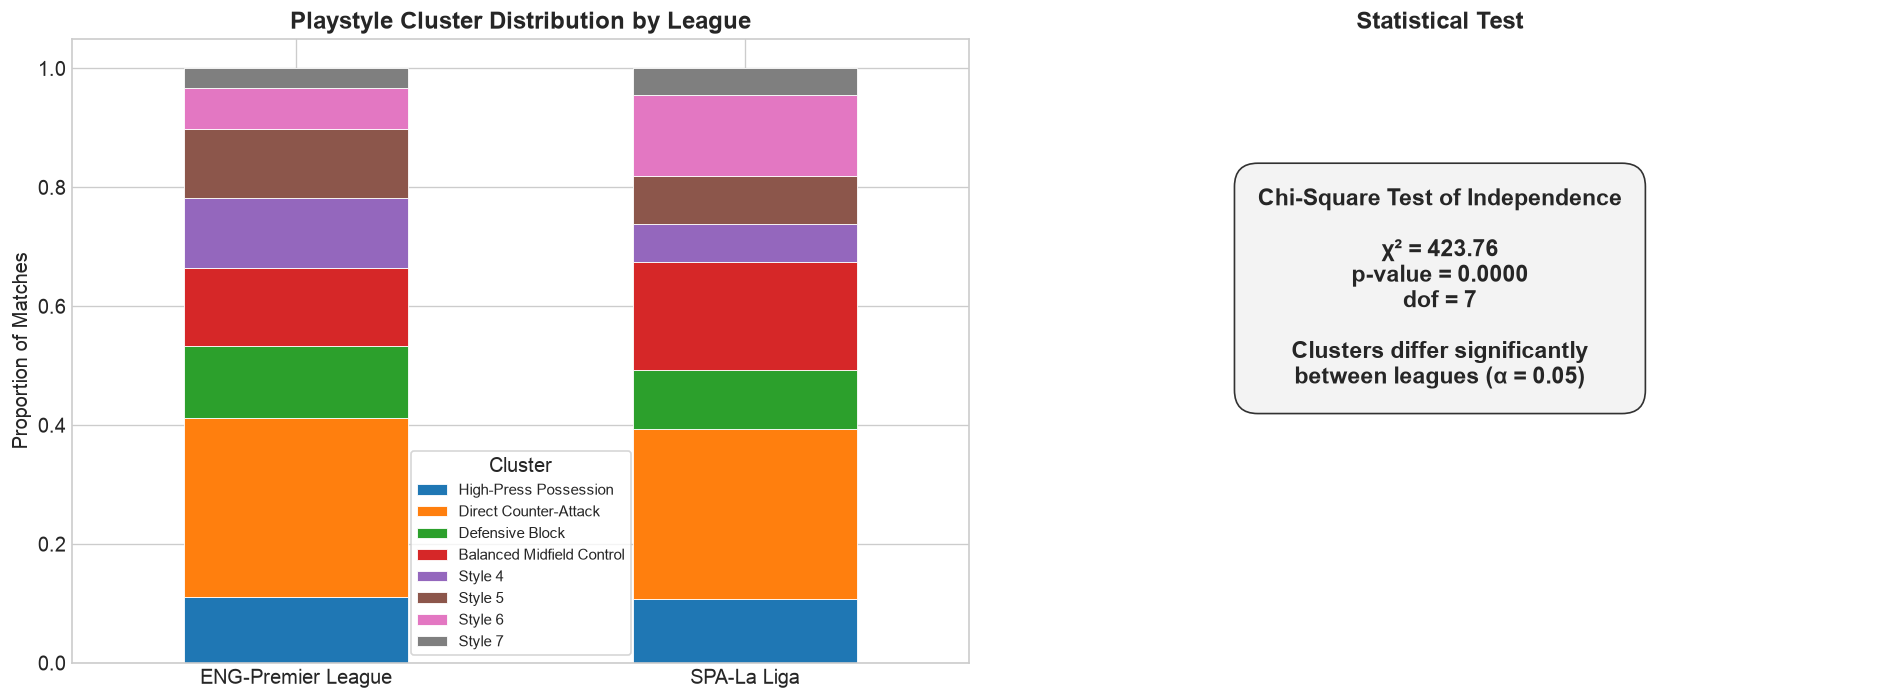

In [14]:
# How differently do playstyle clusters distribute across EPL vs La Liga?
cluster_dist = df.groupby(['league', 'cluster']).size().unstack(fill_value=0)
cluster_dist_pct = cluster_dist.div(cluster_dist.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar
cluster_dist_pct.plot(kind='bar', stacked=True, ax=ax1, 
                      color=[f'C{i}' for i in range(K)],
                      edgecolor='white', linewidth=0.5)
ax1.set_title('Playstyle Cluster Distribution by League', fontweight='bold')
ax1.set_ylabel('Proportion of Matches')
ax1.set_xlabel('')
ax1.legend(title='Cluster', labels=[CLUSTER_NAMES.get(i, f'Cluster {i}') for i in range(K)],
           fontsize=9, frameon=True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Chi-square test for independence
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(cluster_dist)

ax2.text(0.5, 0.6, f'Chi-Square Test of Independence\n\n'
         f'χ² = {chi2:.2f}\n'
         f'p-value = {p_value:.4f}\n'
         f'dof = {dof}\n\n'
         f'{"Clusters differ significantly" if p_value < 0.05 else "No significant difference"}\n'
         f'between leagues (α = 0.05)',
         ha='center', va='center', transform=ax2.transAxes,
         fontsize=14, fontweight='bold',
         bbox=dict(boxstyle='round,pad=1', facecolor='#f0f0f0', alpha=0.8))
ax2.set_title('Statistical Test', fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_distribution_leagues.png'))
plt.show()

---
## 6. Summary of Results

In [15]:
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Best EPL model
best_epl = epl_results.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n1. Best EPL Model:")
print(f"   {best_epl['Model']} with {best_epl['Feature Set']}")
print(f"   Accuracy: {best_epl['Accuracy']:.3f}, F1: {best_epl['F1 Macro']:.3f}")

# Cluster value-add
baseline_f1 = epl_results[
    (epl_results['Feature Set'] == 'Baseline (Identity + Form)') & 
    (epl_results['Model'] == best_epl['Model'])
]['F1 Macro'].values

if len(baseline_f1) > 0:
    improvement = best_epl['F1 Macro'] - baseline_f1[0]
    print(f"\n2. Value of Clustering:")
    print(f"   F1 improvement over baseline: {improvement:+.3f}")
    print(f"   {'Clustering ADDS predictive value' if improvement > 0 else 'Clustering does NOT improve prediction'}")

# Cross-league transfer
if len(transfer_df) > 0:
    best_transfer = transfer_df.sort_values('F1 Macro', ascending=False).iloc[0]
    print(f"\n3. Cross-League Transfer (EPL → La Liga):")
    print(f"   Best: {best_transfer['Model']} — Accuracy: {best_transfer['Accuracy']:.3f}, F1: {best_transfer['F1 Macro']:.3f}")
    
    laliga_within = laliga_results[
        (laliga_results['Feature Set'] == 'Clusters + Form') & 
        (laliga_results['Model'] == best_transfer['Model'])
    ]['F1 Macro'].values
    
    if len(laliga_within) > 0:
        gap = laliga_within[0] - best_transfer['F1 Macro']
        print(f"   Gap vs within-league La Liga: {gap:+.3f}")
        if gap < 0.05:
            print(f"   → Clusters GENERALIZE well across leagues")
        else:
            print(f"   → Clusters are partially league-specific")

print(f"\n4. Optimal Number of Clusters: K={K}")
for k, name in CLUSTER_NAMES.items():
    print(f"   Cluster {k}: {name}")

print("\n" + "=" * 70)

RESULTS SUMMARY

1. Best EPL Model:
   Random Forest with Full (Clusters + Form + Identity)
   Accuracy: 0.653, F1: 0.612

2. Value of Clustering:
   F1 improvement over baseline: +0.114
   Clustering ADDS predictive value

3. Cross-League Transfer (EPL → La Liga):
   Best: XGBoost — Accuracy: 0.644, F1: 0.595
   Gap vs within-league La Liga: +0.004
   → Clusters GENERALIZE well across leagues

4. Optimal Number of Clusters: K=8
   Cluster 0: High-Press Possession
   Cluster 1: Direct Counter-Attack
   Cluster 2: Defensive Block
   Cluster 3: Balanced Midfield Control
   Cluster 4: Style 4
   Cluster 5: Style 5
   Cluster 6: Style 6
   Cluster 7: Style 7



---
## 7. Interactive Exploration (Plotly)

Interactive scatter plot for exploring individual match predictions.

In [16]:
# Interactive PCA plot with hover info
from sklearn.decomposition import PCA as PCA2

plot_features = [f for f in FEATURE_COLS if f in df.columns]

if len(plot_features) < 2:
    print("Not enough features for PCA plot")
else:
    X_plot = StandardScaler().fit_transform(df[plot_features].fillna(0))
    pca_2d = PCA2(n_components=2)
    coords = pca_2d.fit_transform(X_plot)

    plot_df = df[['squad', 'opponent', 'date', 'result', 'league', 'season', 'cluster']].copy()
    plot_df['PC1'] = coords[:, 0]
    plot_df['PC2'] = coords[:, 1]
    plot_df['cluster_name'] = plot_df['cluster'].map(CLUSTER_NAMES)

    fig = px.scatter(
        plot_df, x='PC1', y='PC2', color='cluster_name',
        hover_data=['squad', 'opponent', 'date', 'result', 'league'],
        opacity=0.5, title='Interactive: All Matches in PCA Space (colored by cluster)',
        labels={'PC1': f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)',
                'PC2': f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)'},
    )
    fig.update_layout(height=700, width=1000)
    fig.show()

---
## 8. Next-Season Outlook: Title Likelihood & Top-Team Playstyles

**Caveat:** this is a heuristic estimate based on each team's most recent-season performance and market-implied win probability, standardized and passed through a softmax — it is **not** a fixture-by-fixture simulation of an actual next season (no such schedule exists in this dataset, which ends at the 2024-2025 season). Consistent with the softmax-based soft-clustering framing used throughout this project, we treat "title likelihood" as a probability distribution over teams within each league, derived from a blend of points-per-game and implied win probability in the most recent season.

### 8.1 Title Likelihood (softmax over current team strength)

In [17]:
LEAGUE_LABELS = {'ENG-Premier League': 'EPL', 'SPA-La Liga': 'La Liga'}

title_likelihoods = {}

for league_code, league_label in LEAGUE_LABELS.items():
    league_df = df[df['league'] == league_code]
    latest_season = sorted(league_df['season'].unique())[-1]
    season_df = league_df[league_df['season'] == latest_season]

    strength = season_df.groupby('squad').agg(
        points_per_game=('match_points', 'mean'),
        implied_win_prob=('implied_win_prob', 'mean'),
    )

    # Standardize both signals and blend into one strength score
    z_ppg = (strength['points_per_game'] - strength['points_per_game'].mean()) / strength['points_per_game'].std()
    z_wp = (strength['implied_win_prob'] - strength['implied_win_prob'].mean()) / strength['implied_win_prob'].std()
    strength['strength_score'] = 0.6 * z_ppg + 0.4 * z_wp

    # Softmax over strength score -> title likelihood (sums to 1 within league)
    exp_scores = np.exp(strength['strength_score'])
    strength['title_likelihood'] = exp_scores / exp_scores.sum()

    strength = strength.sort_values('title_likelihood', ascending=False)
    title_likelihoods[league_label] = strength

    print(f"\n{league_label} — Title Likelihood (based on {latest_season} form, heuristic softmax)")
    print(strength[['points_per_game', 'implied_win_prob', 'title_likelihood']].head(10).round(3))


EPL — Title Likelihood (based on 2024-2025 form, heuristic softmax)
               points_per_game  implied_win_prob  title_likelihood
squad                                                             
Liverpool                2.211             0.642             0.200
Arsenal                  1.947             0.599             0.127
Man City                 1.868             0.604             0.117
Chelsea                  1.816             0.527             0.087
Newcastle                1.737             0.469             0.066
Aston Villa              1.737             0.434             0.059
Brighton                 1.605             0.410             0.047
Nott'm Forest            1.711             0.345             0.044
Bournemouth              1.474             0.387             0.037
Brentford                1.474             0.336             0.032

La Liga — Title Likelihood (based on 2024-2025 form, heuristic softmax)
             points_per_game  implied_win_prob  title_

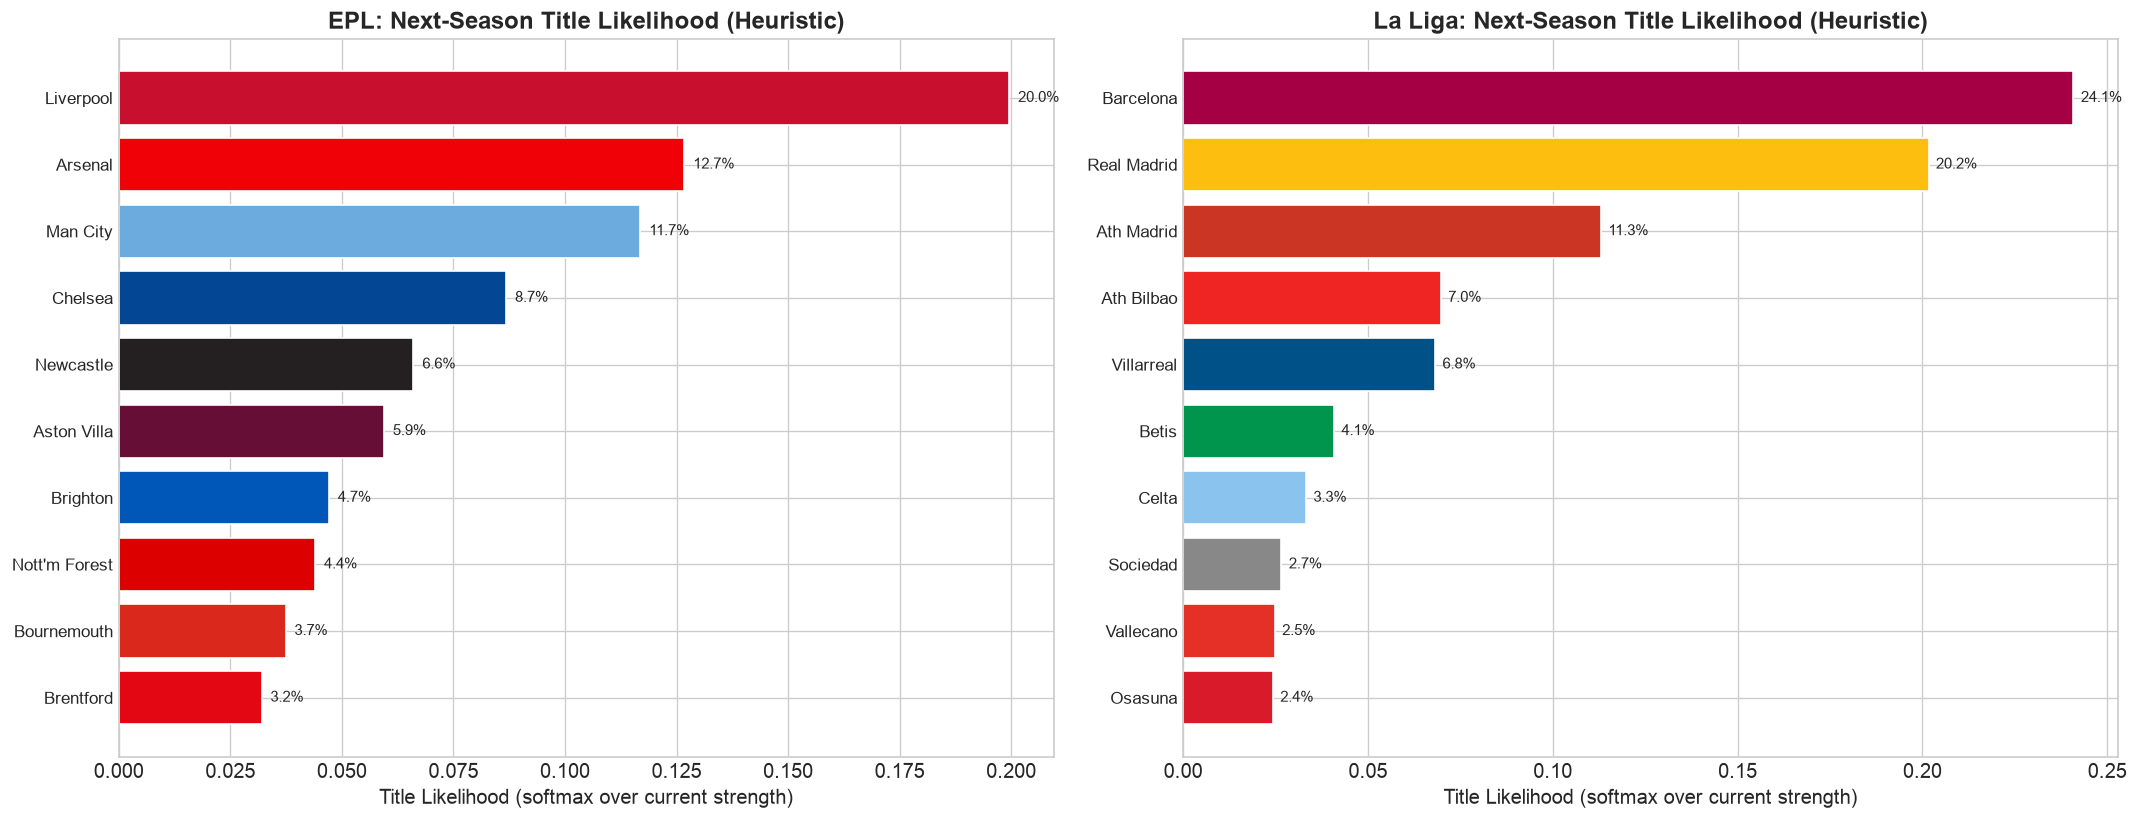

In [18]:
# Bar chart: title likelihood by team, one panel per league
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (league_label, strength) in zip(axes, title_likelihoods.items()):
    top10 = strength.head(10)
    colors = [get_club_color(t) for t in top10.index]

    ax.barh(range(len(top10)), top10['title_likelihood'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Title Likelihood (softmax over current strength)', fontsize=12)
    ax.set_title(f'{league_label}: Next-Season Title Likelihood (Heuristic)', fontweight='bold')

    for i, v in enumerate(top10['title_likelihood']):
        ax.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'title_likelihood_next_season.png'))
plt.show()

### 8.2 Top 5 Teams per League — Soft Playstyle Profiles

For the top 5 highest-title-likelihood teams in each league, we show their average **soft (GMM/softmax) cluster-membership vector** — the same probabilistic playstyle assignment used for match prediction — along with a few representative raw playstyle attributes.

In [19]:
prob_cols = [f'cluster_{k}_prob' for k in range(K)]
attribute_cols = [c for c in ['shot_dominance', 'shot_accuracy', 'corner_dominance',
                               'discipline_index', 'implied_win_prob'] if c in df.columns]

top5_by_league = {}

for league_label, strength in title_likelihoods.items():
    league_code = [code for code, label in LEAGUE_LABELS.items() if label == league_label][0]
    top5_teams = strength.head(5).index.tolist()
    top5_by_league[league_label] = top5_teams

    team_data = df[(df['league'] == league_code) & (df['squad'].isin(top5_teams))]
    cluster_profile = team_data.groupby('squad')[prob_cols].mean().reindex(top5_teams)
    cluster_profile.columns = [CLUSTER_NAMES.get(k, f'Cluster {k}') for k in range(K)]
    attr_profile = team_data.groupby('squad')[attribute_cols].mean().reindex(top5_teams)

    print(f"\n{'=' * 90}")
    print(f"TOP 5 {league_label} TEAMS — Playstyle Profile (soft cluster membership)")
    print(f"{'=' * 90}")

    for team in top5_teams:
        dominant = cluster_profile.loc[team].idxmax()
        dominant_pct = cluster_profile.loc[team].max()
        mix_str = ", ".join(f"{c}={v:.1%}" for c, v in cluster_profile.loc[team].items())
        attr_str = ", ".join(f"{a}={v:.2f}" for a, v in attr_profile.loc[team].items())

        print(f"\n{team}  (Title Likelihood: {strength.loc[team, 'title_likelihood']:.1%})")
        print(f"  Dominant playstyle: {dominant} ({dominant_pct:.1%} avg. membership)")
        print(f"  Full cluster mix:   {mix_str}")
        print(f"  Key attributes:     {attr_str}")


TOP 5 EPL TEAMS — Playstyle Profile (soft cluster membership)

Liverpool  (Title Likelihood: 20.0%)
  Dominant playstyle: Style 5 (40.0% avg. membership)
  Full cluster mix:   High-Press Possession=5.8%, Direct Counter-Attack=30.4%, Defensive Block=13.4%, Balanced Midfield Control=4.0%, Style 4=0.5%, Style 5=40.0%, Style 6=5.1%, Style 7=0.9%
  Key attributes:     shot_dominance=0.65, shot_accuracy=0.37, corner_dominance=0.64, discipline_index=14.54, implied_win_prob=0.52

Arsenal  (Title Likelihood: 12.7%)
  Dominant playstyle: Direct Counter-Attack (34.2% avg. membership)
  Full cluster mix:   High-Press Possession=5.2%, Direct Counter-Attack=34.2%, Defensive Block=16.2%, Balanced Midfield Control=7.9%, Style 4=3.2%, Style 5=23.4%, Style 6=7.6%, Style 7=2.3%
  Key attributes:     shot_dominance=0.56, shot_accuracy=0.36, corner_dominance=0.57, discipline_index=18.09, implied_win_prob=0.46

Man City  (Title Likelihood: 11.7%)
  Dominant playstyle: Style 5 (43.7% avg. membership)
  Full

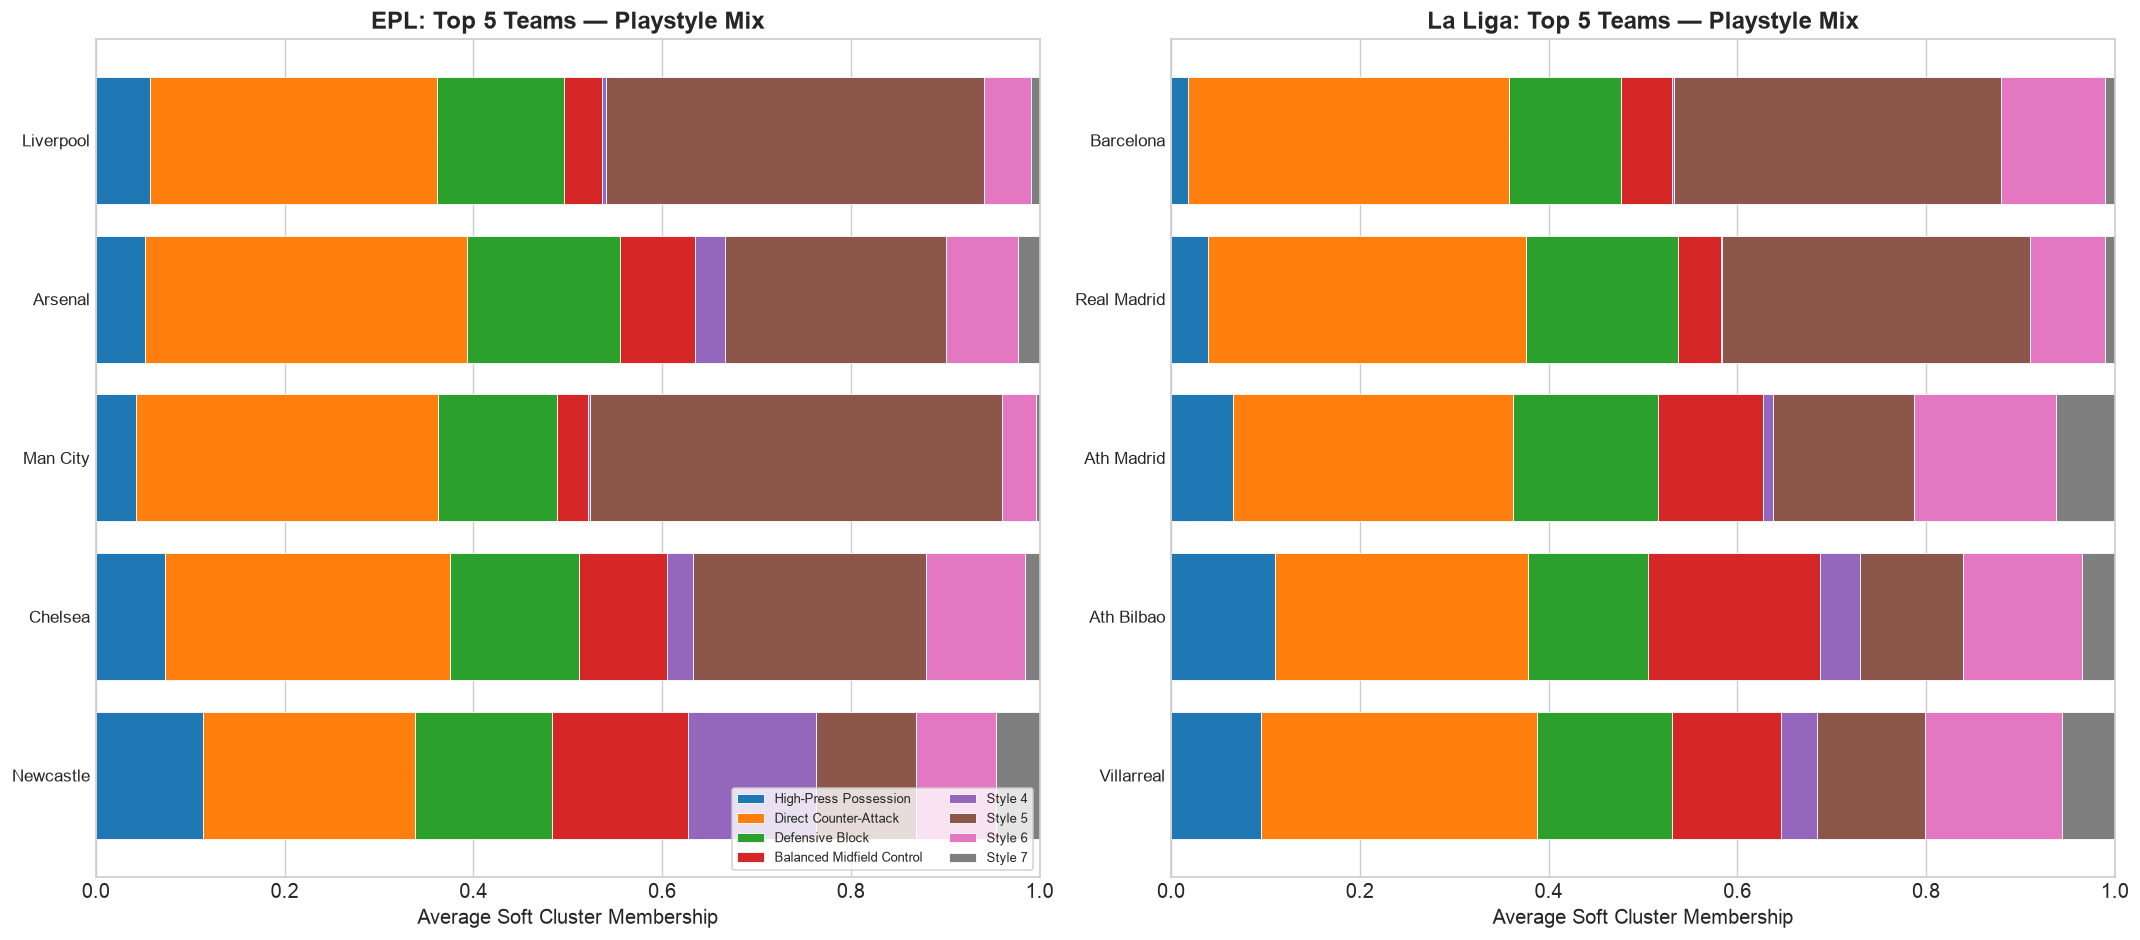

In [20]:
# Stacked bar chart: soft playstyle mix for the top 5 teams in each league
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (league_label, strength) in zip(axes, title_likelihoods.items()):
    league_code = [code for code, label in LEAGUE_LABELS.items() if label == league_label][0]
    top5_teams = top5_by_league[league_label]

    team_data = df[(df['league'] == league_code) & (df['squad'].isin(top5_teams))]
    cluster_profile = team_data.groupby('squad')[prob_cols].mean().reindex(top5_teams)

    bottom = np.zeros(len(cluster_profile))
    for k in range(K):
        col = f'cluster_{k}_prob'
        vals = cluster_profile[col].values
        ax.barh(range(len(cluster_profile)), vals, left=bottom,
                color=f'C{k}', label=CLUSTER_NAMES.get(k, f'Cluster {k}'),
                edgecolor='white', linewidth=0.5)
        bottom += vals

    ax.set_yticks(range(len(cluster_profile)))
    ax.set_yticklabels(cluster_profile.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xlabel('Average Soft Cluster Membership', fontsize=12)
    ax.set_title(f'{league_label}: Top 5 Teams — Playstyle Mix', fontweight='bold')

axes[0].legend(loc='lower right', fontsize=8, frameon=True, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top5_playstyle_mix.png'))
plt.show()

---
## Next Steps for Final Report

1. **Run with real data** from Notebook 01 (replace synthetic placeholders)
2. **Manually name clusters** after inspecting the cluster profile heatmap in Notebook 02
3. **Tune hyperparameters** via grid search if time permits
4. **Add rest days** feature (gap between matches) if available in scraped data
5. **Write up findings** for the final report, referencing saved figures in `figures/`